# Computing the collision probabilities of different unique DNA molecules into the same consensus molecule via equal cuts and equal tagging

### How to compute required input

#### (optional) 0. Sort the files in case they are not sorted
This might not be needed for the immediate next step but might be useful for exploring some example cases

```
# in case you want to resort the BAM file
samtools sort -@ 7 P_6_2_J_1.sorted.bam -o P_6_2_J_1.resorted.bam --write-index
```

#### 1. Starting from a BAM file you can run this 
This will report for each read which is the starting and end position of the alignment.

```
for file in $(ls *.sorted.bam); do
  sample=${file%.bam}
  echo "$sample"

  samtools view -@ 15 ${sample}.bam | \
  awk '
  function cigar_len(cigar,   len,op,total) {
      total=0
      while (match(cigar, /[0-9]+[MIDNSHP=X]/)) {
          len=substr(cigar, RSTART, RLENGTH-1)
          op=substr(cigar, RSTART+RLENGTH-1, 1)
          if (op ~ /[MDN=X]/) total += len
          cigar=substr(cigar, RSTART+RLENGTH)
      }
      return total
  }

  BEGIN{OFS="\t"}

  {
    chr=$3
    pos=$4
    cigar=$6

    if (chr=="*" || cigar=="*") next

    len = cigar_len(cigar)
    end = pos + len - 1

    print $1, chr, pos, end
  }' | gzip > ${sample}.read_coords.tsv.gz

done
```


#### 2. Merge the information of each pair of reads and report how many times a given set of cuts is unique
```
for file in $(ls *_2.sorted.bam | cut -d '.' -f1); do
echo $file;
python /data/bbg/projects/prominent/protocols/paper_figures/supplementary_analysis/UMIcollisions/compute_unique_cuts_freq.py $file /data/bbg/nobackup2/prominent/duplex_seq_tests/error_rate/cord_blood/bbg/2026-03-17_tws_idt ;
done;
```

Example of output:

```
$ zcat SC001_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
repeats	frequency
1	46,353,191
2	2,430,718
3	254,679
4	37,477
5	7,193
6	1,687
7	485
8	191
9	80
10	39
11	19
12	9
14	6
16	3
13	2
18	1
17	1
```


In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import brentq

import matplotlib.pyplot as plt

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
run = "/data/bbg/nobackup2/prominent/duplex_seq_tests/error_rate/cord_blood/bbg/2026-03-17_tws_idt"

In [3]:
cord_blood_samples_list = ["SC003_B1_1_H_1", "SC002_B1_1_H_1", "SC001_B1_1_H_1",
                           "SC003_B1_1_H_2", "SC002_B1_1_H_2", "SC001_B1_1_H_2"]
reference_sample = "SC001_B1_1_H_2"


In [4]:
# sample = [
# #             "TS_DNA_TS_FEZ_TS_Adapters_idt_v2",
# #             "TS_DNA_IDT_EZF",
# #             "TS_DNA_75uM_IDT_idt_v3_speedvac",
#             "Cord_Blood_3_Ultrashear",
#             # "Cord_Blood_3_IDT_EZF_FPGUDG_338",
#             # "Cord_Blood_3_IDT_EZF_354",
#             "Cord_Blood_3_bufferR1_1",
#             # "Cord_Blood_3_3uM_KapaPCR",
#             # "Cord_Blood_3_3uM_IDTPCR",
#             # "Cord_Blood_3_15uM_KapaPCR",
#         ]
# sample = "Cord_Blood_3_bufferR1_1"
# # sample = "Cord_Blood_3_Ultrashear"
# run = "/data/bbg/nobackup2/prominent/duplex_seq_tests/technology_tests/rosana_data/2025-11-03.tests/2025-11-04_deepUMIcaller"

## Read cut frequency files and plot them

In [5]:
all_counts_df = pd.DataFrame()
for file in os.listdir(f"{run}/processing_files/sortbamamfiltered/"):
    if file.endswith(".sorted.read_coords.cuts_freq.tsv.gz"):
        print(file)
        sample = file.split('.')[0]
        sample_counts = pd.read_csv(f"{run}/processing_files/sortbamamfiltered/{file}", sep="\t")
        sample_counts["sample"] = sample
        sample_counts["relative_frequency"] = sample_counts["frequency"] / sample_counts["frequency"].sum()
        # sample_counts["expected_poisson_cuts"] = (sample_counts["relative_frequency"] * sample_counts["repeats"]).sum()
        all_counts_df = pd.concat([all_counts_df, sample_counts], ignore_index=True)


SC002_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
SC001_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
SC003_B1_1_H_2.sorted.read_coords.cuts_freq.tsv.gz
SC001_B1_1_H_1.sorted.read_coords.cuts_freq.tsv.gz
SC002_B1_1_H_1.sorted.read_coords.cuts_freq.tsv.gz
SC003_B1_1_H_1.sorted.read_coords.cuts_freq.tsv.gz


In [6]:
all_counts_df["total_fragments"] = all_counts_df["repeats"] * all_counts_df["frequency"]
all_counts_df["repeated"] = all_counts_df["repeats"] > 1
repeated_frequency = all_counts_df.groupby(by = ["sample", "repeated"])["total_fragments"].sum()
repeated_frequency

sample          repeated
SC001_B1_1_H_1  False       72605095
                True         9930665
SC001_B1_1_H_2  False       46353191
                True         5828011
SC002_B1_1_H_1  False       91013953
                True        13236728
SC002_B1_1_H_2  False       57106533
                True         8601399
SC003_B1_1_H_1  False       97322864
                True        14360079
SC003_B1_1_H_2  False       68727524
                True        15478474
Name: total_fragments, dtype: int64

In [7]:
all_counts_df.head(20)

,repeats,frequency,sample,relative_frequency,total_fragments,repeated
0,1,57106533,SC002_B1_1_H_2,9.348416e-01,57106533,False
1,2,3463947,SC002_B1_1_H_2,5.670528e-02,6927894,True
2,3,424075,SC002_B1_1_H_2,6.942164e-03,1272225,True
3,4,70498,SC002_B1_1_H_2,1.154062e-03,281992,True
4,5,15412,SC002_B1_1_H_2,2.522965e-04,77060,True
5,6,4239,SC002_B1_1_H_2,6.939300e-05,25434,True
6,7,1288,SC002_B1_1_H_2,2.108473e-05,9016,True
7,8,502,SC002_B1_1_H_2,8.217807e-06,4016,True
8,9,176,SC002_B1_1_H_2,2.881144e-06,1584,True
9,10,76,SC002_B1_1_H_2,1.244130e-06,760,True


### Plotting

In [8]:
# all_counts_df[all_counts_df["repeats"] > 20]

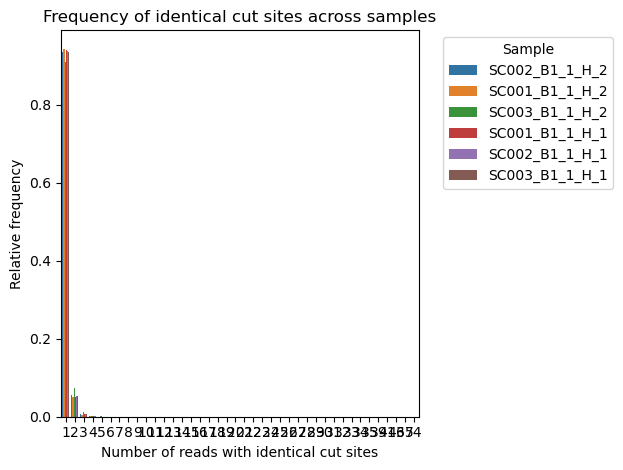

In [9]:
sns.barplot(data=all_counts_df,
             x="repeats",
             y="relative_frequency",             
             hue="sample",
             dodge=True)
# plt.yscale("log")
plt.xlabel("Number of reads with identical cut sites")
plt.ylabel("Relative frequency")
plt.title("Frequency of identical cut sites across samples")
plt.legend(title="Sample", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [10]:
per_sample_repeated_frequency = repeated_frequency.unstack(fill_value=0)
per_sample_repeated_frequency = per_sample_repeated_frequency.div(per_sample_repeated_frequency.sum(axis=1), axis=0)
per_sample_repeated_frequency

repeated,False,True
sample,,
SC001_B1_1_H_1,0.879680,0.120320
SC001_B1_1_H_2,0.888312,0.111688
SC002_B1_1_H_1,0.873030,0.126970
SC002_B1_1_H_2,0.869096,0.130904
SC003_B1_1_H_1,0.871421,0.128579
SC003_B1_1_H_2,0.816183,0.183817


## UMI counts

In [11]:
def get_single_umi_probabilities_vector(sample, run, plot = False, verbose=False):
    umi_counts_data = pd.read_table(f"{run}/metrics/duplex/fgbio_seqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.umi_counts.txt")
    umi_counts_data = umi_counts_data.sort_values("fraction_raw_observations", ascending = False).reset_index(drop=True)
    umi_counts_data["cummulative_fraction"] = umi_counts_data["fraction_raw_observations"].cumsum()

    major_freq_df = umi_counts_data.iloc[:100,:]
    minor_freq_df = umi_counts_data.iloc[100:,:]
    minor_freq = minor_freq_df.sum()
    minor_freq["umi"] = str(len(minor_freq_df)) + 'umis'
    minor_freq["cummulative_fraction"] = 1
    merged_umis = pd.concat([major_freq_df, minor_freq.to_frame().T], ignore_index=True)
    merged_umis = merged_umis.reset_index()

    # plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
    if plot:
        sns.lineplot(data=merged_umis, x="index", y="fraction_raw_observations")
        plt.xlabel("UMI Rank")
        plt.ylabel("Fraction of Raw Observations")
        plt.title(f"{sample}\nCumulative Distribution of UMIs")
        plt.show()

    # identify the elbow point in the cumulative distribution of UMIs to determine a cutoff for high-frequency UMIs
    init_val = 1
    i = 0
    diff = 0
    while diff < (init_val / 2):
        new_val = merged_umis.loc[i,"fraction_unique_observations"]
        if verbose:
            print(i, new_val, init_val)
        if i == 0:
            init_val = merged_umis.loc[i,"fraction_unique_observations"]
        else:
            diff = init_val - merged_umis.loc[i,"fraction_unique_observations"]
        init_val = merged_umis.loc[i,"fraction_unique_observations"]
        if verbose:
            print(diff)
        i += 1

    umi_tag_probabilities = merged_umis.loc[:i-1,"fraction_unique_observations"].values
    umi_tag_probabilities_norm = umi_tag_probabilities / umi_tag_probabilities.sum()

    return i, umi_tag_probabilities, umi_tag_probabilities_norm


In [12]:
unique_tags_number, umi_tag_probabilities, umi_tag_probabilities_norm = get_single_umi_probabilities_vector(reference_sample, run, verbose=False)
umi_tag_probabilities_norm

array([0.08717805325131266, 0.08743195742980407, 0.08033656766546357,
       0.061574441598289315, 0.05635601436861959, 0.046508389015483875,
       0.04551955544270926, 0.03611760155899309, 0.036880385420115,
       0.03684074637115221, 0.033730688016044175, 0.031446621735269006,
       0.03075775934383447, 0.030510283119228907, 0.026202482690055852,
       0.02490832130770294, 0.023902346524566038, 0.021375089321775877,
       0.020809429379820298, 0.020118424337090476, 0.019028886153437403,
       0.017471178661764283, 0.017544028805804017, 0.016484487740284954,
       0.01484428817374331, 0.013336932987509416, 0.013095884716789711,
       0.012727348694000471, 0.011827435149980236, 0.01143318731164756,
       0.008941283855229623, 0.004759899852478459], dtype=object)

In [13]:
tag_probabilities_assume_random_side = np.matmul(umi_tag_probabilities.reshape(-1, 1), umi_tag_probabilities.reshape(1, -1)).flatten()
tag_probabilities_assume_random_side

array([0.006621727876, 0.006641013514, 0.006102073512, ...,
       4.7415695999999996e-05, 3.708127799999999e-05, 1.9740249e-05],
      shape=(1024,), dtype=object)

Effective barcode diversity

In [14]:
probability_of_same_tag_2_frag = np.sum(tag_probabilities_assume_random_side ** 2) 
D_eff = 1 / probability_of_same_tag_2_frag
D_eff

610.5133573132524

## Estimate UMI collisions

In [15]:
def func(N, p):
    """
    p: numpy array of probabilities
    N: number of independent trials
    """
    return np.sum(1 - (1 - p) ** N)


def find_N(p, target):
    """
    p: numpy array of probabilities
    target: target value for the sum
    """
    # Define a function that we want to find the root of
    def objective(N):
        return func(N, p) - target
    
    # Use brentq to find the root of the objective function
    N_solution = brentq(objective, 1, 1e6)  # Search for N in the range [1, 1e6]
    
    return N_solution

In [16]:
all_counts_df

,repeats,frequency,sample,relative_frequency,total_fragments,repeated
0,1,57106533,SC002_B1_1_H_2,9.348416e-01,57106533,False
1,2,3463947,SC002_B1_1_H_2,5.670528e-02,6927894,True
2,3,424075,SC002_B1_1_H_2,6.942164e-03,1272225,True
3,4,70498,SC002_B1_1_H_2,1.154062e-03,281992,True
4,5,15412,SC002_B1_1_H_2,2.522965e-04,77060,True
...,...,...,...,...,...,...
157,31,1,SC003_B1_1_H_1,9.626100e-09,31,True
158,26,1,SC003_B1_1_H_1,9.626100e-09,26,True
159,27,1,SC003_B1_1_H_1,9.626100e-09,27,True
160,30,1,SC003_B1_1_H_1,9.626100e-09,30,True


In [17]:
def compute_original_fragments_per_sample(counts_df, vector_of_probabilities):
    n_repeats_observed = counts_df["repeats"].unique().tolist()
    n_repeats_observed.remove(1)
    # print(list(n_repeats_observed))

    mapping_observed_repeats_to_original_cuts = {1:1}
    for n_repeats in n_repeats_observed:
        N_solution = find_N(vector_of_probabilities, n_repeats)
        mapping_observed_repeats_to_original_cuts[n_repeats] = N_solution

    return mapping_observed_repeats_to_original_cuts

In [26]:
upd_counts_df = pd.DataFrame()
for sample in cord_blood_samples_list:
    unique_tags_number, umi_tag_probabilities, umi_tag_probabilities_norm = get_single_umi_probabilities_vector(sample, run, plot = False, verbose=False)
    print(f"{sample}: main_UMI_tags\t= {unique_tags_number}")

    tag_probabilities_assume_random_side = np.matmul(umi_tag_probabilities.reshape(-1, 1), umi_tag_probabilities.reshape(1, -1)).flatten()
    probability_of_same_tag_2_frag = np.sum(tag_probabilities_assume_random_side ** 2) 
    D_eff = 1 / probability_of_same_tag_2_frag
    print(f"{sample}: D_eff\t\t= {D_eff:.0f}")

    vector_of_probabilities = tag_probabilities_assume_random_side

    sample_count_df = all_counts_df[all_counts_df["sample"] == sample].copy()
    mapping_observed_repeats_to_original_cuts = compute_original_fragments_per_sample(sample_count_df, vector_of_probabilities)

    sample_count_df["original_fragments_per_cutsite"] = sample_count_df["repeats"].map(mapping_observed_repeats_to_original_cuts)
    sample_count_df["original_fragments"] = sample_count_df["original_fragments_per_cutsite"] * sample_count_df["frequency"]
    lost_fragments = sample_count_df["original_fragments"].sum() - sample_count_df["total_fragments"].sum()
    
    print(f"{sample}: Lost fragments\t= {lost_fragments:,.0f}")

    lost_proportion = lost_fragments / sample_count_df["original_fragments"].sum()

    print(f"{sample}: Lost proportion\t= {lost_proportion:.2%}")
    upd_counts_df = pd.concat([upd_counts_df, sample_count_df], ignore_index=True)

    print()


SC003_B1_1_H_1: main_UMI_tags	= 98
SC003_B1_1_H_1: D_eff		= 8302
SC003_B1_1_H_1: Lost fragments	= 2,291,528
SC003_B1_1_H_1: Lost proportion	= 2.01%

SC002_B1_1_H_1: main_UMI_tags	= 98
SC002_B1_1_H_1: D_eff		= 8479
SC002_B1_1_H_1: Lost fragments	= 2,297,154
SC002_B1_1_H_1: Lost proportion	= 2.16%

SC001_B1_1_H_1: main_UMI_tags	= 98
SC001_B1_1_H_1: D_eff		= 8288
SC001_B1_1_H_1: Lost fragments	= 1,568,985
SC001_B1_1_H_1: Lost proportion	= 1.87%

SC003_B1_1_H_2: main_UMI_tags	= 32
SC003_B1_1_H_2: D_eff		= 571
SC003_B1_1_H_2: Lost fragments	= 2,128,365
SC003_B1_1_H_2: Lost proportion	= 2.47%

SC002_B1_1_H_2: main_UMI_tags	= 32
SC002_B1_1_H_2: D_eff		= 581
SC002_B1_1_H_2: Lost fragments	= 1,151,971
SC002_B1_1_H_2: Lost proportion	= 1.72%

SC001_B1_1_H_2: main_UMI_tags	= 32
SC001_B1_1_H_2: D_eff		= 611
SC001_B1_1_H_2: Lost fragments	= 870,752
SC001_B1_1_H_2: Lost proportion	= 1.64%



## Duplex UMI counts

In [84]:
# umi_counts_data = pd.read_table(f"{run}/collectduplexseqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.umi_counts.txt")
umi_counts_data = pd.read_table(f"{run}/metrics/duplex/fgbio_seqmetricsontarget/{sample}_chr1.on_target.duplex_seq_metrics.duplex_umi_counts.txt")
umi_counts_data = umi_counts_data.sort_values("fraction_raw_observations", ascending = False).reset_index(drop=True)
umi_counts_data["cummulative_fraction"] = umi_counts_data["fraction_raw_observations"].cumsum()
umi_counts_data.head()

,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,fraction_unique_observations_expected,cummulative_fraction
0,AAGACCTT-AGCAATTG,23081,1123,1963,0.000512,0.000436,0.000412,0.000512
1,AGAGTCCT-AAGACCTT,23055,1132,1918,0.000511,0.000426,0.000423,0.001023
2,AAGACCTT-AGAGTCCT,22601,1086,1937,0.000501,0.000431,0.000423,0.001524
3,AAGACCTT-AGATGACC,22476,1158,1886,0.000498,0.000419,0.000407,0.002022
4,AGCAATTG-AAGACCTT,22071,1045,1980,0.000489,0.000440,0.000412,0.002511


In [85]:
umi_counts_data.iloc[920:1050,:]

,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,fraction_unique_observations_expected,cummulative_fraction
920,TAGAGCCA-GCAGCACA,9624,512,874,0.000213,0.000194,0.000183,0.258259
921,GACGGAAC-AGAGTCCT,9588,425,870,0.000213,0.000193,0.000191,0.258472
922,GCCTCTAC-GTAAGGAC,9602,528,850,0.000213,0.000189,0.000193,0.258685
923,CCAAGACG-AAGCGCTC,9622,444,882,0.000213,0.000196,0.000187,0.258898
924,CTACATAG-TAGAGCCA,9587,429,865,0.000213,0.000192,0.000178,0.259111
...,...,...,...,...,...,...,...,...
1045,CAGACGGA-GTAAGGAC,9219,506,764,0.000204,0.000170,0.000165,0.284291
1046,AAGACCTT-ATTAAGCG,9219,389,859,0.000204,0.000191,0.000192,0.284495
1047,CATTGTGG-AAGAATCT,9213,369,827,0.000204,0.000184,0.000175,0.284699
1048,CAGCTTCG-GACAGAGA,9203,434,783,0.000204,0.000174,0.000165,0.284903


In [86]:
for threshold in [0.95, 0.99, 0.995, 0.999]:
    major_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] <= threshold]
    minor_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] > threshold]
    print(f"Threshold: {threshold}: major: {len(major_freq_df)}, minor: {len(minor_freq_df)}")
    print()


major_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] <= 0.999]
minor_freq_df = umi_counts_data[umi_counts_data["cummulative_fraction"] > 0.999]
# major_freq_df = umi_counts_data.iloc[:100000,:]
# minor_freq_df = umi_counts_data.iloc[100000:,:]

print(len(major_freq_df), len(minor_freq_df))

minor_freq = minor_freq_df[['raw_observations', 'raw_observations_with_errors',
                            'unique_observations', 'fraction_raw_observations',
                            'fraction_unique_observations', 'fraction_unique_observations_expected',]].sum()
minor_freq["umi"] = str(len(minor_freq_df)) + ' umis'
minor_freq["cummulative_fraction"] = 1
minor_freq

Threshold: 0.95: major: 7858, minor: 384629

Threshold: 0.99: major: 44304, minor: 348183

Threshold: 0.995: major: 164978, minor: 227509

Threshold: 0.999: major: 345347, minor: 47140

345347 47140


raw_observations                            47140.0
raw_observations_with_errors                    0.0
unique_observations                         47140.0
fraction_raw_observations                  0.001045
fraction_unique_observations               0.010479
fraction_unique_observations_expected      0.003458
umi                                      47140 umis
cummulative_fraction                              1
dtype: object

In [87]:
merged_umis = pd.concat([major_freq_df, minor_freq.to_frame().T], ignore_index=True)
merged_umis = merged_umis.reset_index()
merged_umis.head()

,index,umi,raw_observations,raw_observations_with_errors,unique_observations,fraction_raw_observations,fraction_unique_observations,fraction_unique_observations_expected,cummulative_fraction
0,0,AAGACCTT-AGCAATTG,23081,1123,1963,0.000512,0.000436,0.000412,0.000512
1,1,AGAGTCCT-AAGACCTT,23055,1132,1918,0.000511,0.000426,0.000423,0.001023
2,2,AAGACCTT-AGAGTCCT,22601,1086,1937,0.000501,0.000431,0.000423,0.001524
3,3,AAGACCTT-AGATGACC,22476,1158,1886,0.000498,0.000419,0.000407,0.002022
4,4,AGCAATTG-AAGACCTT,22071,1045,1980,0.000489,0.00044,0.000412,0.002511


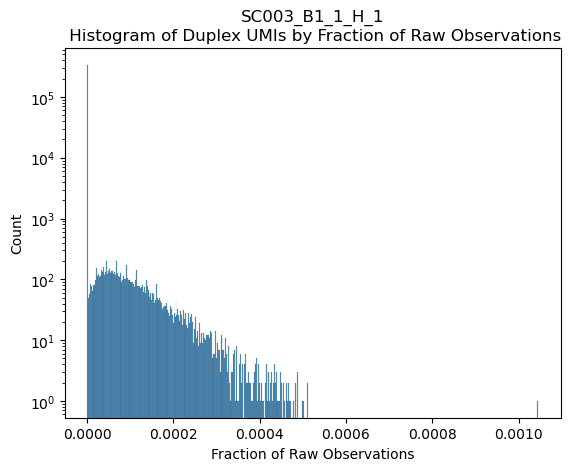

In [88]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.histplot(data=merged_umis, x="fraction_raw_observations", bins=500)
plt.xlabel("Fraction of Raw Observations")
plt.title(f"{sample}\n Histogram of Duplex UMIs by Fraction of Raw Observations")
# plt.xscale("log")
plt.yscale("log")
plt.show()

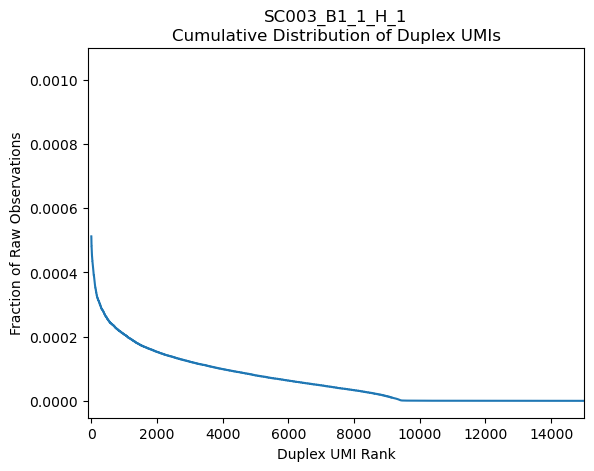

In [92]:
# plot cumsumative distribution of duplex UMIs (fraction_raw_observations)
sns.lineplot(data=merged_umis, x="index", y="fraction_raw_observations")
plt.xlabel("Duplex UMI Rank")
plt.ylabel("Fraction of Raw Observations")
plt.title(f"{sample}\nCumulative Distribution of Duplex UMIs")
plt.xlim(-100, 15000)
plt.show()

# REMOVE

## TEST -All molecules

In [ ]:
data = pd.read_csv(f"{run}/processing_files/sortbamamfiltered/{sample}.sorted.read_coords.head.tsv.gz",
                   sep="\t",
                   header=None)

In [ ]:
data.columns = ["READ_NAME", "CHROM", "START", "END"]
data.head(20)

,READ_NAME,CHROM,START,END
0,SC001_B1_1_H_2_chr1:1090,chr1,777639,777770
1,SC001_B1_1_H_2_chr1:1090,chr1,777586,777717
2,SC001_B1_1_H_2_chr1:1153,chr1,788768,788899
3,SC001_B1_1_H_2_chr1:1153,chr1,788738,788864
4,SC001_B1_1_H_2_chr1:1156,chr1,789009,789140
5,SC001_B1_1_H_2_chr1:1156,chr1,789241,789372
6,SC001_B1_1_H_2_chr1:1168,chr1,790199,790330
7,SC001_B1_1_H_2_chr1:1168,chr1,790018,790149
8,SC001_B1_1_H_2_chr1:1176,chr1,790940,791071
9,SC001_B1_1_H_2_chr1:1176,chr1,790850,790981


In [ ]:
merged_cuts = (
    data
    .groupby(["READ_NAME", "CHROM"])
    .agg(
        START_first=("START", "min"),
        END_first=("END", "min"),
        START_last=("START", "max"),
        END_last=("END", "max"),
    )
    .reset_index()
)

In [ ]:
first_in_pair = data.sort_values(by = ["READ_NAME", "CHROM", "START"]).drop_duplicates(subset=["READ_NAME"], keep='first')
last_in_pair = data.sort_values(by = ["READ_NAME", "CHROM", "START"]).drop_duplicates(subset=["READ_NAME"], keep='last')

In [ ]:
merged_cuts = first_in_pair.merge(last_in_pair, on=["READ_NAME", 'CHROM'], suffixes=("_first", "_last"))
merged_cuts

NameError: name 'first_in_pair' is not defined

In [ ]:
identical_cuts_size = merged_cuts.groupby(["CHROM", "START_first", "END_first", "START_last", "END_last"]).size()
frequency_identical_cuts_size = identical_cuts_size.to_frame().reset_index().rename(columns={0: "count"})
frequency_identical_cuts_size
# frequency_identical_cuts_size = identical_cuts_size.value_counts().to_frame().reset_index().rename(columns={"index": "repeats", 0: "count"})
# frequency_identical_cuts_size

,CHROM,START_first,END_first,START_last,END_last,count
0,chr1,777586,777717,777639,777770,1
1,chr1,788738,788864,788768,788899,1
2,chr1,789009,789140,789241,789372,1
3,chr1,790018,790149,790199,790330,1
4,chr1,790850,790981,790940,791071,1
...,...,...,...,...,...,...
468653,chr1,11210632,11210763,11210965,11211096,1
468654,chr1,11210632,11210763,11211009,11211140,1
468655,chr1,11210632,11210763,11211089,11211220,1
468656,chr1,11210657,11210747,11210887,11211017,1


In [ ]:
# merged_cuts[merged_cuts.duplicated(subset = ["START_first", "END_first", "START_last", "END_last"], keep=False)]

In [ ]:
frequency_identical_cuts_size["count"].value_counts().to_frame(
    name = 'frequency').reset_index().rename(
        columns={"count": "repeats"}).to_csv(
            f"{run}/processing_files/sortbamamfiltered/{sample}.sorted.read_coords.cuts_freq.tsv.gz",
            sep="\t", index=False, compression="gzip")

,repeats,frequency
0,1,440519
1,2,25405
2,3,2351
3,4,314
4,5,58
5,6,6
6,7,4
7,8,1
